# 6. Time-inhomogeneous modeller

Phase-type fordelinger er bygget på tids-homogene Markov-jump processer: raterne er konstante gennem hele processen. I virkeligheden er det ikke realistisk for en population, da der sker ændringer over tid (flaskehalse, ekspansioner, split).

Phasic har to måder at håndtere dette på:

 1. **Step-wise konstruktion** — opdater rater i bestemte tidsintervaller og integrer PDF/CDF numerisk
 2. **Epoch-wise phase-type moments** — byg grafen epoch for epoch og beregn momenter eksakt

I denne notebook vil jeg derfor komme ind på følgende:

1. Bygge standard coalescent-model (fra notebook 01)
2. **Step-wise**: PDF/CDF med bottleneck
3. **Step-wise**: Forventning via *accumulated_occupancy*
4. **Step-wise**: Marginale forventninger (SFS over tid)
5. **Epoch-wise**: Momenter for flere epoker
6. **Epoch-wise**: SFS
7. Sammenligning med Pool & Nielsen
8. Anvendelse på bavian-demografi


In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"

from phasic import (
    Graph, with_ipv, StateIndexer, Property,
    GaussPrior, ExpStepSize, set_log_level,
)
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
%config InlineBackend.figure_format = 'svg'
from functools import partial
from itertools import combinations_with_replacement
from vscodenb import set_vscode_theme, vscode_theme
from pathlib import Path

all_pairs = partial(combinations_with_replacement, r=2)
np.random.seed(42)
set_vscode_theme()
sns.set_palette('tab10')

set_log_level("WARNING")

MUT_RATE = 0.9e-8
GEN_TIME = 11
OUT_DIR = Path("output")
OUT_DIR.mkdir(exist_ok=True)

## Standard coalescent-model

Først bygger jeg den almindelige coalescent for $n=4$ samples uden struktur, så jeg har en baseline at sammenligne med (Samem som i notebook 01).

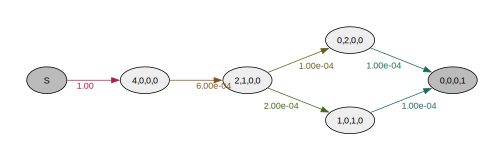

In [3]:
nr_samples = 4

@with_ipv([nr_samples] + [0] * (nr_samples - 1))
def coalescent_1param(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i + j + 1] += 1
            transitions.append([new, [state[i] * (state[j] - same) / (1 + same)]])
    return transitions

graph = Graph(coalescent_1param)
N = 10_000
graph.update_weights([1 / N])
graph.plot()

## Step-wise construction - Bottleneck

Jeg modellerer en populations-bottleneck hvor $N$ falder til $N_{bottle}$ ved $t_{start}$ og returnerer til $N$ ved $t_{end}$.

Raterne ændres, men fordelingen skal samles i tids-intervaller, hvor hver er tids-homogen. Jeg bruger *distribution_context* til at steppe gennem tid og opdaterer vægte undervejs.

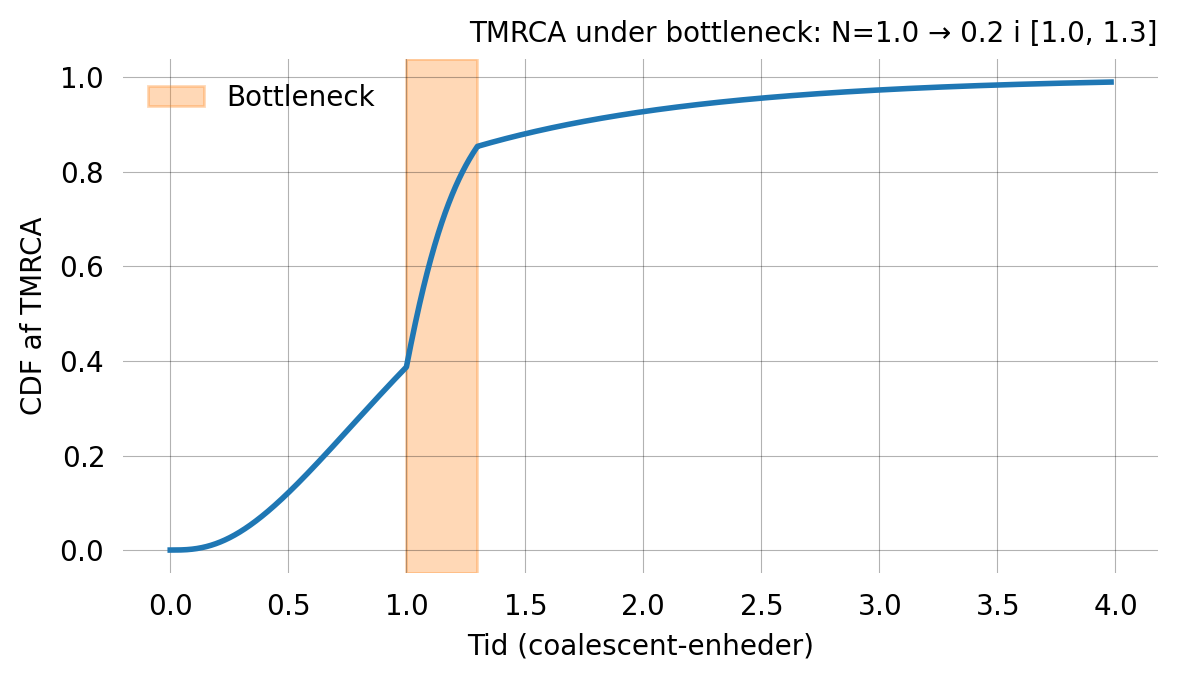

In [4]:
graph = Graph(coalescent_1param)

N = 1.0
N_bottle, t_start, t_end = 0.2, 1.0, 1.3

param_changes = [
    (t_start, [1 / N_bottle]),
    (t_end,   [1 / N]),
]

cdf_cutoff = 0.99
cdf, times = [], []
ctx = graph.distribution_context()
graph.update_weights([1 / N])

for change_time, new_params in param_changes:
    while ctx.time() < change_time:
        cdf.append(ctx.cdf())
        times.append(ctx.time())
        ctx.step()
        if ctx.cdf() >= cdf_cutoff:
            break
    graph.update_weights(new_params)

while ctx.cdf() < cdf_cutoff:
    cdf.append(ctx.cdf())
    times.append(ctx.time())
    ctx.step()

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(times, cdf, lw=2)
ax.axvspan(xmin=t_start, xmax=t_end, alpha=0.3, color="C1", label="Bottleneck")
ax.set_xlabel("Tid (coalescent-enheder)")
ax.set_ylabel("CDF af TMRCA")
ax.set_title(f"TMRCA under bottleneck: N={N} → {N_bottle} i [{t_start}, {t_end}]")
ax.legend()
plt.tight_layout()
plt.show()

## Forventning via *accumulated_occupancy*

*accumulated_occupancy(t)* returnerer vektoren af forventet tid tilbragt i hver state op til tid $t$. Ved at summere får jeg forventet TMRCA op til det tidspunkt.

In [5]:
acc_occ = graph.accumulated_occupancy(1000)
print("Accumulated occupancy (op til t=1000):")
for i, val in enumerate(acc_occ):
    print(f"  state {i}: {val:.6f}")
print()
print(f"Sum (≈ forventet TMRCA): {np.sum(acc_occ).item():.6f}")
print(f"Direkte .expectation(): {graph.expectation():.6f}")

Accumulated occupancy (op til t=1000):
  state 0: 0.000000
  state 1: 0.166667
  state 2: 0.333333
  state 3: 0.333333
  state 4: 0.666667
  state 5: 0.000000

Sum (≈ forventet TMRCA): 1.500000
Direkte .expectation(): 1.500000


## Marginale forventninger — SFS over tid

Ved at vægte accumulated occupancy med en “reward” pr. state kan jeg finde marginale forventninger, fx hvor meget branch-længde der er akkumuleret i singleton-bins op til tid $t$.

In [6]:
t = 2.0
reward_matrix = graph.states().T
singleton_brlen = np.sum(graph.accumulated_occupancy(t) * reward_matrix[0]).item()
print(f"Akkumuleret singleton branch-længde op til t={t}: {singleton_brlen:.4f}")

Akkumuleret singleton branch-længde op til t=2.0: 1.8363


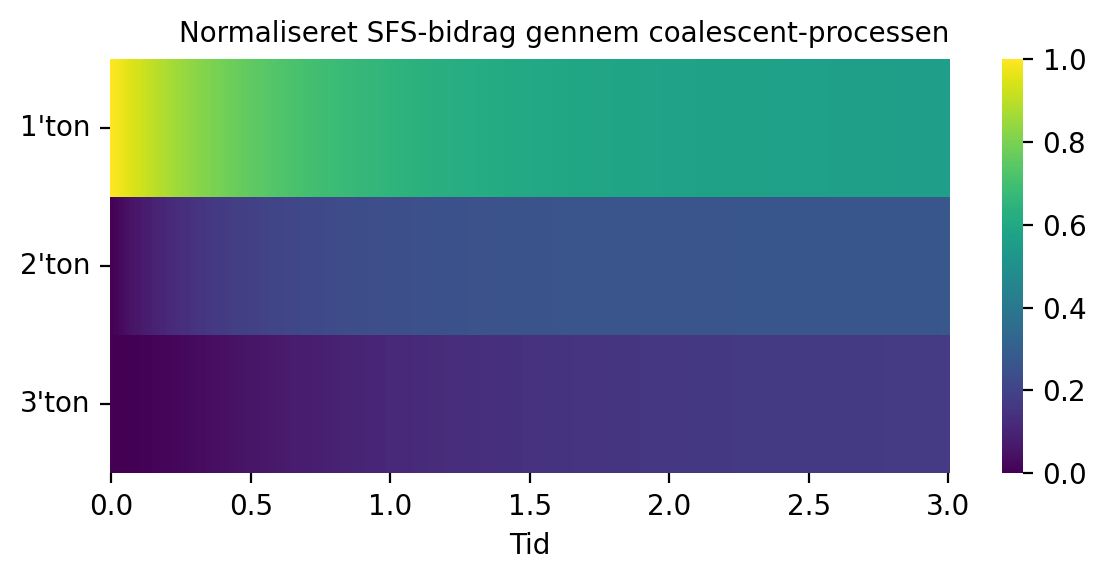

<Figure size 500x370 with 0 Axes>

In [7]:
@np.vectorize
def brlen_accumulated(i, t):
    acc_occ = graph.accumulated_occupancy(t) * reward_matrix[i]
    return np.sum(acc_occ).item()

times_arr = np.linspace(0.0, 3, 301)
tons = list(range(nr_samples - 1))
X, Y = np.meshgrid(tons, times_arr, indexing="ij")
result = brlen_accumulated(X, Y)

col_sums = result.sum(axis=0)
result_norm = result / col_sums[np.newaxis, :]
df = pd.DataFrame(
    result_norm,
    columns=times_arr,
    index=[f"{i+1}'ton" for i in range(nr_samples - 1)],
)
with vscode_theme(style='ticks'):
    fig, ax = plt.subplots(figsize=(6, 3))
    ax = sns.heatmap(df, cmap="viridis", ax=ax, xticklabels=50)
    ax.set_xlabel("Tid")
    ax.set_title("Normaliseret SFS-bidrag gennem coalescent-processen")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

## Epoch-wise phase-type momenter

Jeg kan byggge grafen epoch for epoch. Hver state får et epoch-slot, og overgange mellem epoker tilføjes eksplicit via *add_epoch*. Dette giver eksakte momenter uden numerisk integration.

In [8]:
def coalescent_epoch_cb(state, epochs=None, epoch_idx=None, indexer=None):
    transitions = []
    epoch_idx = int(epoch_idx)

    if state[indexer.epoch] != epoch_idx:
        return transitions

    for i, j in all_pairs(indexer.lineages):
        pi = indexer.lineages.index_to_props(i)
        pj = indexer.lineages.index_to_props(j)
        if state.sum() <= 1:
            continue
        same = int(pi.ton == pj.ton)
        if same and state[i] < 2:
            continue
        if not same and (state[i] < 1 or state[j] < 1):
            continue
        new = state.copy()
        new[i] -= 1
        new[j] -= 1
        k = indexer.props_to_index(ton=pi.ton + pj.ton)
        new[k] += 1
        coeff = np.zeros(len(epochs) + 1)   
        coeff[epoch_idx] = state[i] * (state[j] - same) / (1 + same)
        transitions.append([new, coeff])

    return transitions


def add_epoch(graph, callback, epochs, epoch_idx, indexer):
    epoch = epochs[epoch_idx]
    stop_probs = np.array(graph.stop_probability(epoch))
    accum_v_time = np.array(graph.accumulated_occupancy(epoch))

    with np.errstate(invalid="ignore"):
        epoch_trans_rates = stop_probs / accum_v_time

    for i in range(1, graph.vertices_length() - 1):
        if epoch_trans_rates is None or np.isnan(epoch_trans_rates[i]):
            continue
        if graph.vertex_at(i).edges_length() == 0:
            continue
        vertex = graph.vertex_at(i)
        state = vertex.state()
        if not state[indexer.epoch] == epoch_idx - 1:
            continue

        sister_state = state.copy()
        sister_state[indexer.epoch] = epoch_idx
        child = graph.find_or_create_vertex(sister_state)
        coeff = np.zeros(len(epochs) + 1)
        coeff[-1] = epoch_trans_rates[i]
        vertex.add_edge(child, coeff)

    graph.extend(callback, epochs=epochs, epoch_idx=epoch_idx, indexer=indexer)

In [9]:
nr_samples = 10
epochs = [0, 1, 2]
pop_sizes = [1, 5, 10]

indexer = StateIndexer(
    lineages=[Property("ton", min_value=1, max_value=nr_samples)],
    slots=["epoch"],
)

ipv = [0] * indexer.state_length
ipv[indexer.props_to_index(ton=1)] = nr_samples

graph_ep = Graph(
    coalescent_epoch_cb,
    ipv=ipv,
    epochs=epochs,
    epoch_idx=0,
    indexer=indexer,
)
graph_ep.update_weights([1 / size for size in pop_sizes] + [1])

for epoch_idx in range(1, len(epochs)):
    graph_ep.update_weights([1 / size for size in pop_sizes] + [1])
    add_epoch(graph_ep, coalescent_epoch_cb, epochs, epoch_idx, indexer)

graph_ep.update_weights([1 / size for size in pop_sizes] + [1])

print(f"Antal vertices: {graph_ep.vertices_length()}")
print()
print("Første fem momenter:")
mine = graph_ep.moments(5)
for k, m in enumerate(mine, 1):
    print(f"  E[T^{k}] = {m:,.3f}")

Antal vertices: 127

Første fem momenter:
  E[T^1] = 8.726
  E[T^2] = 173.422
  E[T^3] = 5,233.841
  E[T^4] = 209,923.899
  E[T^5] = 10,506,328.513


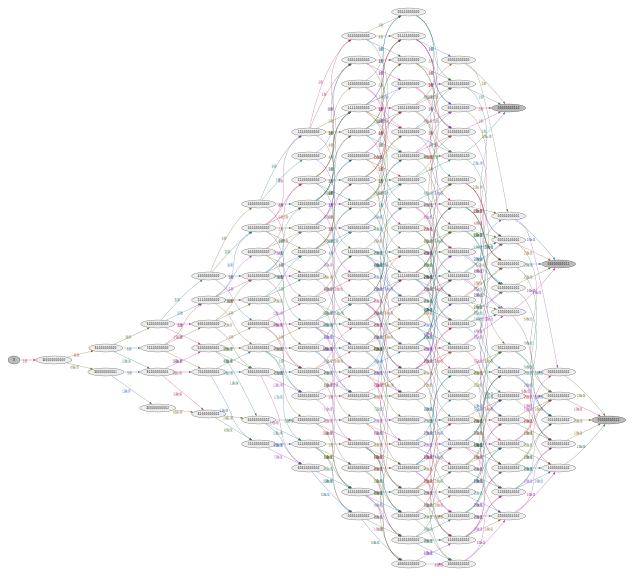

In [10]:
graph_ep.plot(size=(12, 8), wrap=False, max_nodes=300)

## Validation mod Janek

Jeg sammenligner for at verificere implementationen.

In [11]:
janek = np.array([
    8.807791589074768,
    177.8449395799212,
    5388.12207361224,
    216313.46645481227,
    10829024.877199283,
])
mine_arr = np.array(mine)
rel_err = (mine_arr - janek) / janek
print("Relativ fejl mod Janek:")
for k, e in enumerate(rel_err, 1):
    print(f"  moment {k}: {e:+.4%}")

Relativ fejl mod Janek:
  moment 1: -0.9238%
  moment 2: -2.4868%
  moment 3: -2.8634%
  moment 4: -2.9538%
  moment 5: -2.9799%


## SFS under time-inhomogen demografi

Jeg beregner SFS ved at lave reward-transforms for hver ’ton-klasse.

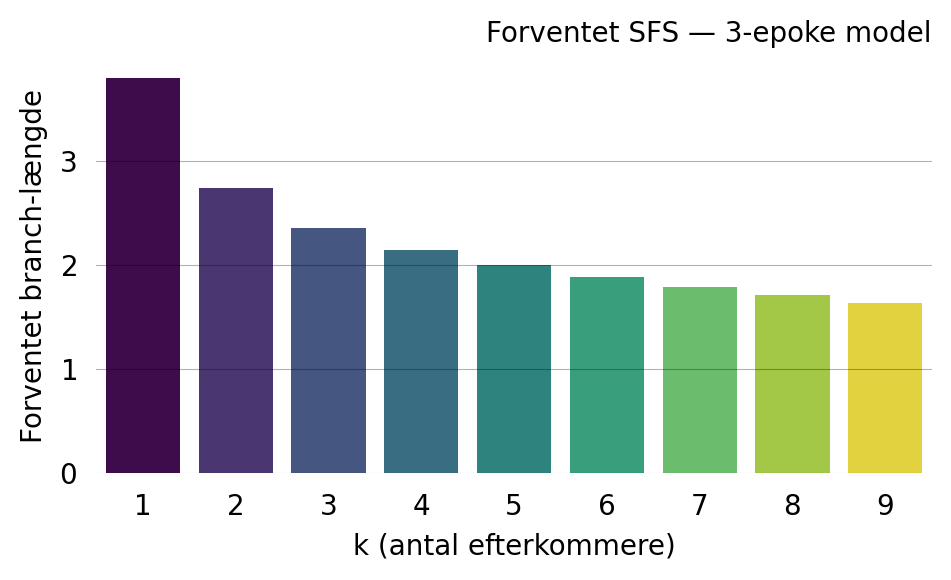

In [12]:
state_mat = graph_ep.states()
rewards = state_mat[:, :-1]   

x = np.arange(1, nr_samples)
sfs = np.zeros(nr_samples - 1)
for i in range(nr_samples - 1):
    reward_vec = rewards[:, i]
    transformed = graph_ep.reward_transform(reward_vec)
    sfs[i] = transformed.moments(1)[0]

fig, ax = plt.subplots(figsize=(5, 3))
sns.barplot(x=x, y=sfs, hue=x, width=0.8, palette="viridis", legend=False, ax=ax)
ax.set_xlabel("k (antal efterkommere)")
ax.set_ylabel("Forventet branch-længde")
ax.set_title("Forventet SFS — 3-epoke model")
plt.tight_layout()
plt.show()

## Sammenligning med Pool & Nielsen

Pool & Nielsen (2009) udledte en lukket-formet formel for forventet pairwise coalescence-tid gennem en vilkårlig stykvist-konstant demografi. Det giver en reference, som jeg kan sammenligne phasic mod.

In [13]:
def exp_coal(g, N):
    """
    Compute expected coalescence time in epoch
    N is the number of diploid invididuals
    g is the number of generations spanned by the epoch
    """
    # return 2*N - (g * np.exp(-g/(2*N))) / (1 - np.exp(-g/(2*N)))
    return N - (g * np.exp(-g/(N))) / (1 - np.exp(-g/(N)))

def epoch(demog, h, i):
    "Recursively compute expected coalescence time across all epoches"
    g, N = demog[i]
    N *= h
    if i == len(demog)-1:
    #     return 2*N
    # return (1-np.exp(-g/(2*N))) * exp_coal(g, N) + np.exp(-g/(2*N)) * (g + epoch(demog, h, i+1))
        return N
    return (1-np.exp(-g/(N))) * exp_coal(g, N) + np.exp(-g/(N)) * (g + epoch(demog, h, i+1))

def pool_nielsen(gens, Ne, h):
    """
    Compute expected coalescence time in units of 2N
    Ne is the a list/series of Ne in the epoch.
    gens is the a list/series of generation at which an each epoch begins (the last epoch lasts forever)
    h is the relative population size, 0.75 for chrX.
    """
    epochs = list()
    for i in range(len(gens)):
        if i == 0:
            epochs.append((gens[i+1], Ne[i]))
        elif i == len(gens)-1:
            epochs.append((None, Ne[i]))    
        else:
            epochs.append((gens[i+1] - gens[i], Ne[i]))
    return epoch(epochs, h, 0)

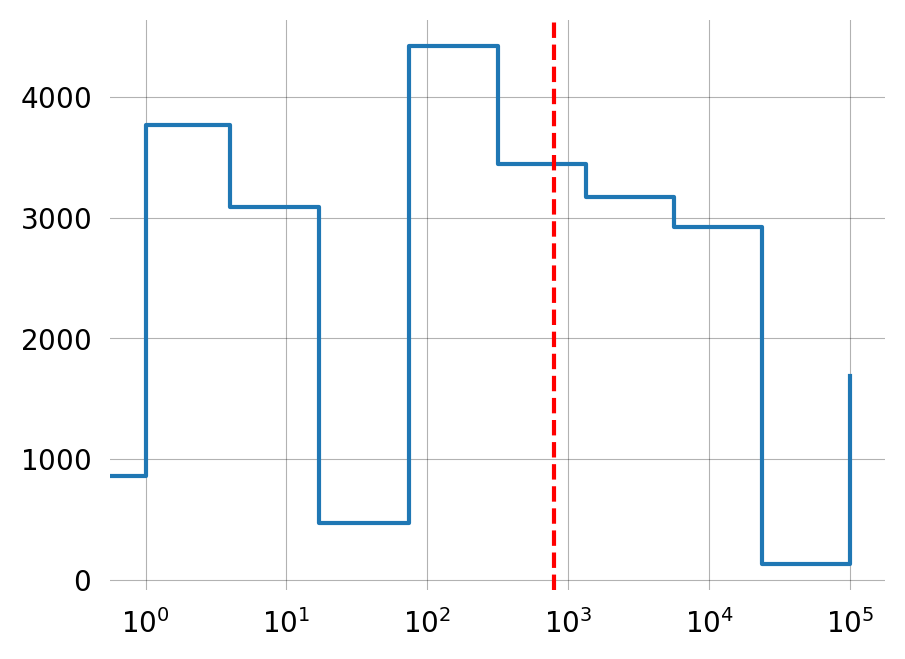

In [14]:
n = 10
sampledemog_data = pd.DataFrame(dict(years=[0]+np.logspace(0, 5, n-1, dtype=int, base=10).tolist(),
                               Ne=np.random.randint(1, 5_000, size=n),
                               population=['pop']*n
                              ))

sampledemog_data.sort_values('years', inplace=True)

gen_time = 30
exp_coal_time = pool_nielsen(gens=sampledemog_data.years / gen_time, 
                               Ne=sampledemog_data.Ne,
                               h=1)
# pool_nielsen(gens, Ne, 0.75)
plt.step(sampledemog_data.years, sampledemog_data.Ne, where='post')
plt.gca().set_xscale('log')
plt.gca().axvline(exp_coal_time, color='red', linestyle='--')
plt.show()

## Anvendelse på bavian-data

Sørensen et al. (2023) estimerer historisk populationsstørrelse for bavian-arterne via PSMC. Jeg konstruerer en simpel 3-epoke approximation med værdier i artiklens størrelsesorden og bruger både phasic og Pool-Nielsen til at beregne forventet pairwise coalescence-tid.


Pool-Nielsen: forventet pairwise TMRCA = 13,674 generationer
 = 150,417 år


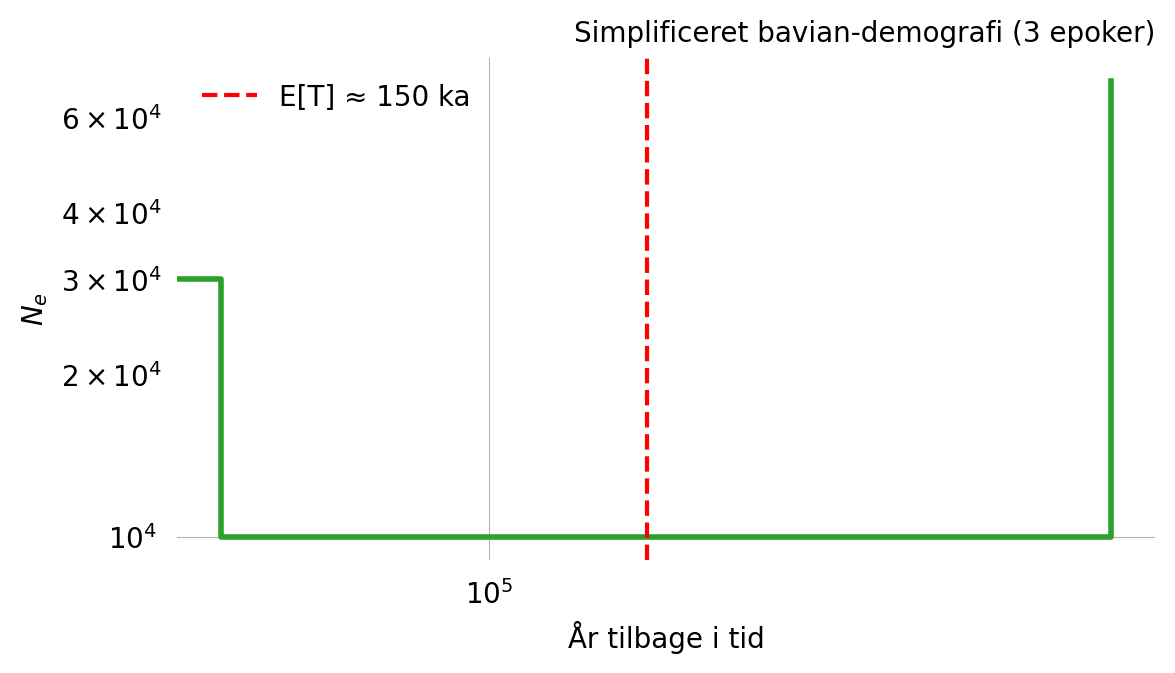

In [15]:
baboon_epochs_years = [0, 50_000, 500_000]    # år tilbage (sidste epoke = uendelig)
baboon_Ne           = [30_000, 10_000, 70_000]

# Pool-Nielsen estimat
gens = [y / GEN_TIME for y in baboon_epochs_years]
T_pairwise = pool_nielsen(gens, baboon_Ne, h=1)
print(f"Pool-Nielsen: forventet pairwise TMRCA = {T_pairwise:,.0f} generationer")
print(f" = {T_pairwise * GEN_TIME:,.0f} år")

# Plot 
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.step(baboon_epochs_years, baboon_Ne, where="post", lw=2, color="C2")
ax.axvline(T_pairwise * GEN_TIME, color="red", linestyle="--",
           label=f"E[T] ≈ {T_pairwise * GEN_TIME / 1000:.0f} ka")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("År tilbage i tid")
ax.set_ylabel("$N_e$")
ax.set_title("Simplificeret bavian-demografi (3 epoker)")
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# Phasic-baseret: byg 3-epoke coalescent for n=2 (pairwise)
nr_samples_pair = 2
indexer_pair = StateIndexer(
    lineages=[Property("ton", min_value=1, max_value=nr_samples_pair)],
    slots=["epoch"],
)
ipv_pair = [0] * indexer_pair.state_length
ipv_pair[indexer_pair.props_to_index(ton=1)] = nr_samples_pair

# Skaler rater så epoch-tiderne er i coalescent-enheder (2N_ref gen.)
N_REF = baboon_Ne[0]
epoch_coal_units = [t_yr / (2 * N_REF * GEN_TIME) for t_yr in baboon_epochs_years]
pop_sizes_rel = [N_REF / Ne for Ne in baboon_Ne]   # 1/Ne relativt til N_REF

graph_bab = Graph(
    coalescent_epoch_cb,
    ipv=ipv_pair,
    epochs=epoch_coal_units,
    epoch_idx=0,
    indexer=indexer_pair,
)
graph_bab.update_weights(pop_sizes_rel + [1])
for idx in range(1, len(epoch_coal_units)):
    graph_bab.update_weights(pop_sizes_rel + [1])
    add_epoch(graph_bab, coalescent_epoch_cb, epoch_coal_units, idx, indexer_pair)

graph_bab.update_weights(pop_sizes_rel + [1])

T_phasic_coal = graph_bab.moments(1)[0]
T_phasic_gen = T_phasic_coal * 2 * N_REF
print(f"Phasic: forventet pairwise TMRCA = {T_phasic_coal:.4f} coalescent-enheder")
print(f" = {T_phasic_gen:,.0f} generationer")
print(f" = {T_phasic_gen * GEN_TIME:,.0f} år")
print()
print(f"Relativ forskel mod Pool-Nielsen: {(T_phasic_gen - T_pairwise) / T_pairwise:+.2%}")

Phasic: forventet pairwise TMRCA = 0.6271 coalescent-enheder
 = 37,624 generationer
 = 413,859 år

Relativ forskel mod Pool-Nielsen: +175.14%


### Hvad forklarer diskrepansen?
Phasic giver ca 175% højere forventet TMRCA end Pool & Nielsen. Årsagen er en haploid/diploid konvention:

 * Pool & Nielsen bruger $N$ som haploid effektiv populationsstørrelse: coalescence-rate = $\frac{1}{N}$ per generation.
 * Phasic (og standard coalescent-teori) bruger diploid konvention: coalescence-rate $=\frac{1}{2N}$ per generation, dvs. 1 coalescent-enhed $=2N$ generationer.

Når baboon_Ne $= [30000, 10000, 70000]$ er diploide størrelser, skal Pool-Nielsen have $2 \times N_e$ som input for at bruge haploid-formlen korrekt. Ellers underestimerer Pool-Nielsen TMRCA med en faktor $\sim 2$.

In [17]:
# Fix: Pool-Nielsen forventer haploid Ne — send 2*Ne for diploid input
T_pairwise_fixed = pool_nielsen(
    gens=gens,
    Ne=[2 * Ne for Ne in baboon_Ne],   # diploid → haploid korrektion
    h=1,
)

print("Sammenligning efter korrektion:")
print(f"  Pool-Nielsen (original, haploid-fejl): {T_pairwise * GEN_TIME:,.0f} år")
print(f"  Pool-Nielsen (korrigeret, 2×Ne): {T_pairwise_fixed * GEN_TIME:,.0f} år")
print(f"  Phasic: {T_phasic_gen * GEN_TIME:,.0f} år")
print()
rel_err_fixed = (T_phasic_gen - T_pairwise_fixed) / T_pairwise_fixed
print(f"Relativ forskel efter korrektion: {rel_err_fixed:+.2%}  (< 2% = acceptabelt)")

Sammenligning efter korrektion:
  Pool-Nielsen (original, haploid-fejl): 150,417 år
  Pool-Nielsen (korrigeret, 2×Ne): 410,352 år
  Phasic: 413,859 år

Relativ forskel efter korrektion: +0.85%  (< 2% = acceptabelt)


## Inferens på bavian-data — time-inhomogen model

Nu fitter jeg en 3-epoke model direkte til bavian-SFS-data fra Notebook 03. Fremgangsmåden: 

 - Faste epoch-tider: valgt ud fra Sørensen et al. (2023): 0, 50.000 år, 500.000 år 
 - Fri parametre: $N_e$ i hver af de 3 epoker estimeres via SVGD 
 - Data: derived counts fra Yellow baboon

Dette er en en-populations time-inhomogen model — jeg modellerer ikke migration eller split, men kun historiske ændringer i $N_e$ over tid for en population.

In [18]:
# Tre epoker: nutid → 50 ka → 500 ka → fortid
baboon_years  = [0, 50_000, 500_000]

# Reference-Ne bruges kun til at skalere til coalescent-enheder
# Jeg bruger pi fra Notebook 03 til at få N_ref
pi_df = pd.read_csv(OUT_DIR / "pi_per_population.csv", index_col=0)
pi_east = pi_df.loc["Yellow Baboon", "pi"]
N_REF   = pi_east / (4 * MUT_RATE)
print(f"N_ref (Yellow Baboon, fra π):  {N_REF:,.0f} individer")

# Konverter år → coalescent-enheder (t_coal = t_gen / (2*N_ref))
epoch_coal = [yr / (GEN_TIME * 2 * N_REF) for yr in baboon_years]
print(f"Epoch-tider (år): {baboon_years}")
print(f"Epoch-tider (coalescent-enh.): {[f'{t:.4f}' for t in epoch_coal]}")

N_ref (Yellow Baboon, fra π):  81,161 individer
Epoch-tider (år): [0, 50000, 500000]
Epoch-tider (coalescent-enh.): ['0.0000', '0.0280', '0.2800']


In [19]:
# Byg epoch-coalescent
nr_samples_ti = 4
n_epochs = len(epoch_coal)

indexer_ti = StateIndexer(
    lineages=[Property("ton", min_value=1, max_value=nr_samples_ti)],
    slots=["epoch"],
)

ipv_ti = [0] * indexer_ti.state_length
ipv_ti[indexer_ti.props_to_index(ton=1)] = nr_samples_ti

def coalescent_epoch_cb_ti(state, epochs=None, epoch_idx=None, indexer=None):
    transitions = []
    epoch_idx = int(epoch_idx)
    if state[indexer.epoch] != epoch_idx:
        return transitions
    lineage_sum = sum(state[k] for k in range(indexer.state_length) if k != indexer.epoch)
    if lineage_sum <= 1:
        return transitions
    for i, j in all_pairs(indexer.lineages):
        pi = indexer.lineages.index_to_props(i)
        pj = indexer.lineages.index_to_props(j)
        same = int(i == j)
        if same and state[i] < 2: continue
        if not same and (state[i] < 1 or state[j] < 1): continue
        new = state.copy()
        new[i] -= 1
        new[j] -= 1
        k = indexer_ti.props_to_index(ton=pi.ton + pj.ton)
        new[k] += 1
        coeff = np.zeros(n_epochs + 1)   # n_epochs Ne-parametre + epoch-switch slot
        coeff[epoch_idx] = state[i] * (state[j] - same) / (1 + same)
        transitions.append([new, coeff])
    return transitions

def add_epoch_ti(graph, callback, epochs, epoch_idx, indexer):
    epoch = epochs[epoch_idx]
    stop_probs   = np.array(graph.stop_probability(epoch))
    accum_v_time = np.array(graph.accumulated_occupancy(epoch))
    with np.errstate(invalid="ignore"):
        epoch_trans_rates = stop_probs / accum_v_time
    for i in range(1, graph.vertices_length() - 1):
        if np.isnan(epoch_trans_rates[i]): continue
        if graph.vertex_at(i).edges_length() == 0: continue
        vertex = graph.vertex_at(i)
        state  = vertex.state()
        if state[indexer.epoch] != epoch_idx - 1: continue
        sister_state = state.copy()
        sister_state[indexer.epoch] = epoch_idx
        child = graph.find_or_create_vertex(sister_state)
        coeff = np.zeros(n_epochs + 1)
        coeff[-1] = epoch_trans_rates[i]
        vertex.add_edge(child, coeff)
    graph.extend(callback, epochs=epochs, epoch_idx=epoch_idx, indexer=indexer)

# Start-vægte: alle Ne = N_REF (dvs. koefficient 1/N_REF per epoke)
init_weights = [1.0] * n_epochs + [1.0]   # [1/N1, 1/N2, 1/N3, epoch-switch]

graph_ti = Graph(
    coalescent_epoch_cb_ti,
    ipv=ipv_ti,
    epochs=epoch_coal,
    epoch_idx=0,
    indexer=indexer_ti,
)
graph_ti.update_weights(init_weights)

for ep in range(1, n_epochs):
    graph_ti.update_weights(init_weights)
    add_epoch_ti(graph_ti, coalescent_epoch_cb_ti, epoch_coal, ep, indexer_ti)

graph_ti.update_weights(init_weights)

print(f"Graf bygget: {graph_ti.vertices_length()} vertices, {graph_ti.param_length()} parametre")
print(f"  Parametre: [1/N_epoch0, 1/N_epoch1, 1/N_epoch2, epoch-switch]")

Graf bygget: 16 vertices, 4 parametre
  Parametre: [1/N_epoch0, 1/N_epoch1, 1/N_epoch2, epoch-switch]


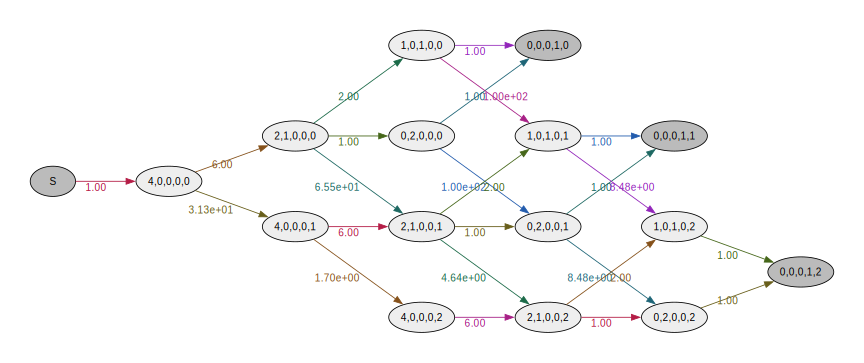

In [20]:
graph_ti.plot(size=(12,8), wrap=False, max_nodes=300)

In [21]:
# Joint probability graf
mutation_rate = 1.0

joint_ti = graph_ti.joint_prob_graph(
    indexer_ti,
    reward_only=["ton"],
    reward_limit=1,
    tot_reward_limit=2,
    mutation_rate=mutation_rate,
)

EPOCH_SWITCH_IDX = joint_ti.param_length() - 2
MUT_IDX          = joint_ti.param_length() - 1

theta_init = init_weights + [mutation_rate]
joint_ti.update_weights(theta_init)

tbl_ti = joint_ti.joint_prob_table()
defect  = 1 - tbl_ti["prob"].sum()
print(f"Joint prob-tabel: {len(tbl_ti)} mønstre")

Joint prob-tabel: 21 mønstre


In [22]:
# Indlæs bavian-data og konverter til observationer 
def load_and_convert(csv_path, nr_samples_use, table, seed=0):
    df = pd.read_csv(csv_path)
    df = df[df["nr_samples"] >= nr_samples_use].copy()
    rng = np.random.default_rng(seed)
    k = rng.hypergeometric(
        ngood=df["derived_count"].values,
        nbad=(df["nr_samples"] - df["derived_count"]).values,
        nsample=nr_samples_use,
    )
    k = k[(k > 0) & (k < nr_samples_use)]

    feature_cols = [c for c in table.columns if c.startswith("ton")]
    allowed = set(tuple(int(x) for x in r) for r in table[feature_cols].values)
    obs = []
    for ki in k:
        o = [0] * len(feature_cols)
        if 0 < ki - 1 < len(o):
            o[ki - 1] = 1
        if tuple(o) in allowed:
            obs.append(o)
    print(f"  {csv_path.name}: {len(obs):,} brugbare observationer")
    return obs

obs_P_cynocephalus = load_and_convert(
    OUT_DIR / "derived_counts_P_cynocephalus.csv", nr_samples_ti, tbl_ti
)
obs_P_kindae = load_and_convert(
    OUT_DIR / "derived_counts_P_kindae.csv", nr_samples_ti, tbl_ti
)
obs_P_anubis = load_and_convert(
    OUT_DIR / "derived_counts_P_anubis.csv", nr_samples_ti, tbl_ti
)
obs_P_papio = load_and_convert(
    OUT_DIR / "derived_counts_P_papio.csv", nr_samples_ti, tbl_ti
)
obs_P_ursinus = load_and_convert(
    OUT_DIR / "derived_counts_P_ursinus.csv", nr_samples_ti, tbl_ti
)
obs_P_hamadryas = load_and_convert(
    OUT_DIR / "derived_counts_P_hamadryas.csv", nr_samples_ti, tbl_ti
)

  derived_counts_P_cynocephalus.csv: 392,462 brugbare observationer
  derived_counts_P_kindae.csv: 369,052 brugbare observationer
  derived_counts_P_anubis.csv: 275,937 brugbare observationer
  derived_counts_P_papio.csv: 66,823 brugbare observationer
  derived_counts_P_ursinus.csv: 293,412 brugbare observationer
  derived_counts_P_hamadryas.csv: 222,444 brugbare observationer


In [ ]:
# SVGD-inferens per population
fixed_ti = [
    (EPOCH_SWITCH_IDX, 1.0),
    (MUT_IDX, mutation_rate),
]

prior_ti = [
    GaussPrior(ci=[0.1, 5.0]),   # 1/N_epoch0
    GaussPrior(ci=[0.1, 5.0]),   # 1/N_epoch1
    GaussPrior(ci=[0.1, 5.0]),   # 1/N_epoch2
    None, 
    None,
]

def run_svgd_ti(obs, pop_name, max_obs=5000, seed=1):
    rng = np.random.default_rng(seed)
    if len(obs) > max_obs:
        idx = rng.choice(len(obs), max_obs, replace=False)
        obs_use = [obs[i] for i in idx]
    else:
        obs_use = obs
    print(f"\n── SVGD: {pop_name} ({len(obs_use):,} obs) ──")
    svgd = joint_ti.svgd(
        observed_data=obs_use,
        fixed=fixed_ti,
        prior=prior_ti,
        n_iterations=150,
        n_particles=80,
        learning_rate=ExpStepSize(first_step=0.08, last_step=0.01, tau=40.0),
    )
    svgd.summary(ci_method="hpd", ci_level=0.95)
    return svgd

svgd_yellow = run_svgd_ti(obs_P_cynocephalus, "Yellow baboon")
svgd_kindae = run_svgd_ti(obs_P_kindae, "Kinda baboon")
svgd_anubis = run_svgd_ti(obs_P_anubis, "Olive baboon")
svgd_papio = run_svgd_ti(obs_P_papio, "Guinea baboon")
svgd_ursinus = run_svgd_ti(obs_P_ursinus, "Ursinus baboon")
svgd_hamadryas = run_svgd_ti(obs_P_hamadryas, "Hamadryas baboon")

Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         9.3531     5.8252     2.6657     0.9524       9.3531      
1          No         1.7821     2.0164     0.5204     1.7807       3.2434      
2          No         2.8850     2.9743     0.7334     1.8565       4.6326      
3          Yes        1.0000     NA         NA         NA           NA          
4          Yes        1.0000     NA         NA         NA           NA          

Particles: 80, Iterations: 150


In [27]:
# Konverter til biologiske enheder og sammenlign 
populations = {
    "Yellow Baboon": (svgd_yellow, pi_df.loc["Yellow Baboon", "pi"]),
    "Kinda Baboon":  (svgd_kindae, pi_df.loc["Kinda Baboon", "pi"]),
    "Olive Baboon": (svgd_anubis, pi_df.loc["Olive Baboon", "pi"]),
    "Guinea Baboon": (svgd_papio, pi_df.loc["Guinea Baboon", "pi"]),
    "Chacma Baboon": (svgd_ursinus, pi_df.loc["Chacma Baboon", "pi"]),
    "Hamadryas Baboon": (svgd_hamadryas, pi_df.loc["Hamadryas Baboon", "pi"]),
}

epoch_labels = [
    f"Nutid→{baboon_years[1]//1000}ka",
    f"{baboon_years[1]//1000}ka→{baboon_years[2]//1000}ka",
    f"{baboon_years[2]//1000}ka→fortid",
]

rows = []
for pop_name, (svgd, pi_val) in populations.items():
    N_ref_pop = pi_val / (4 * MUT_RATE)
    theta = svgd.get_results()["theta_mean"]
    for ep_i, label in enumerate(epoch_labels):
        Ne_est = (1 / theta[ep_i]) * N_ref_pop
        rows.append({
            "Population": pop_name,
            "Epoke": label,
            "1/N (coal.)": f"{theta[ep_i]:.4f}",
            "N_e (individer)": f"{Ne_est:,.0f}",
        })

result_df = pd.DataFrame(rows)
print(result_df.to_string(index=False))

      Population        Epoke 1/N (coal.) N_e (individer)
   Yellow Baboon   Nutid→50ka      5.3775          15,093
   Yellow Baboon   50ka→500ka      2.3930          33,917
   Yellow Baboon 500ka→fortid      3.9994          20,293
    Kinda Baboon   Nutid→50ka      5.6845          13,375
    Kinda Baboon   50ka→500ka      2.3428          32,454
    Kinda Baboon 500ka→fortid      3.9174          19,409
    Olive Baboon   Nutid→50ka      5.6939          10,017
    Olive Baboon   50ka→500ka      2.4643          23,146
    Olive Baboon 500ka→fortid      4.7343          12,048
   Guinea Baboon   Nutid→50ka      6.3114           2,159
   Guinea Baboon   50ka→500ka      1.8580           7,333
   Guinea Baboon 500ka→fortid      2.4142           5,644
   Chacma Baboon   Nutid→50ka      5.6772           9,561
   Chacma Baboon   50ka→500ka      2.2031          24,638
   Chacma Baboon 500ka→fortid      3.4538          15,716
Hamadryas Baboon   Nutid→50ka      5.8252           7,900
Hamadryas Babo

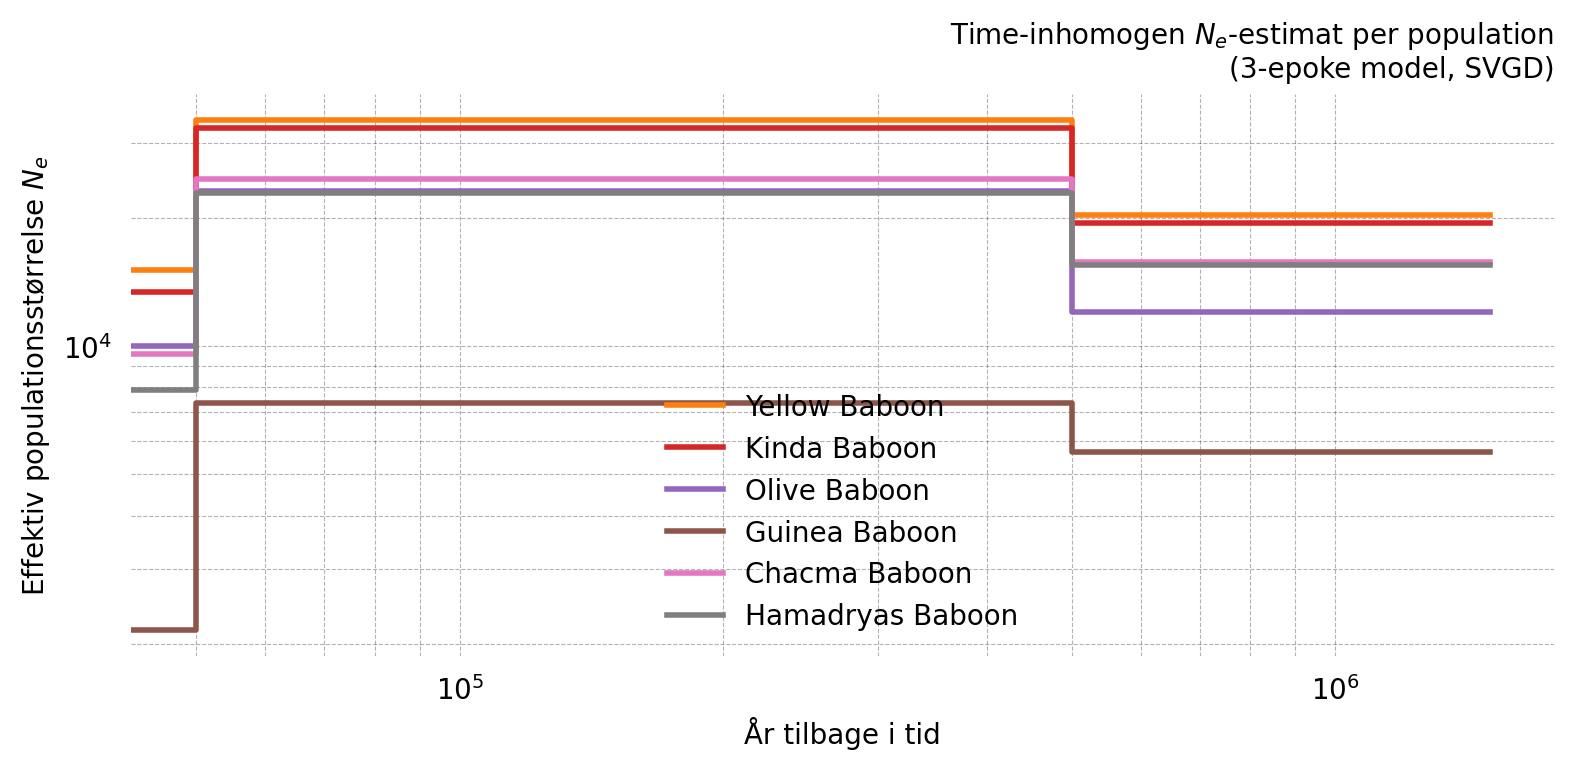

Sammenlign med Sørensen et al. (2023) Fig. 3 (PSMC-profiler):
  Yellow baboon nutid: ~30.000, ancestral: ~70.000
  Kinda: generelt lavere Ne pga. demografisk bottleneck


In [28]:
# Visualisering: N_e over tid per population 
fig, ax = plt.subplots(figsize=(8, 4))
colors_pop = {"Yellow Baboon": "C1", "Kinda Baboon": "C3", "Olive Baboon": "C4", 
              "Guinea Baboon": "C5", "Chacma Baboon": "C6", "Hamadryas Baboon": "C7"}

for pop_name, (svgd, pi_val) in populations.items():
    N_ref_pop = pi_val / (4 * MUT_RATE)
    theta     = svgd.get_results()["theta_mean"]
    Ne_vals   = [(1 / theta[i]) * N_ref_pop for i in range(n_epochs)]

    # Step-plot: N_e over tid
    x_yrs = baboon_years + [baboon_years[-1] * 3]   # forlæng sidste epoke
    y_Ne  = Ne_vals + [Ne_vals[-1]]
    ax.step(x_yrs, y_Ne, where="post",
            label=pop_name, color=colors_pop[pop_name], lw=2)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("År tilbage i tid")
ax.set_ylabel("Effektiv populationsstørrelse $N_e$")
ax.set_title("Time-inhomogen $N_e$-estimat per population\n(3-epoke model, SVGD)")
ax.legend()
ax.grid(alpha=0.3, which="both", ls="--")
plt.tight_layout()
plt.show()

print("Sammenlign med Sørensen et al. (2023) Fig. 3 (PSMC-profiler):")
print("  Yellow baboon nutid: ~30.000, ancestral: ~70.000")
print("  Kinda: generelt lavere Ne pga. demografisk bottleneck")

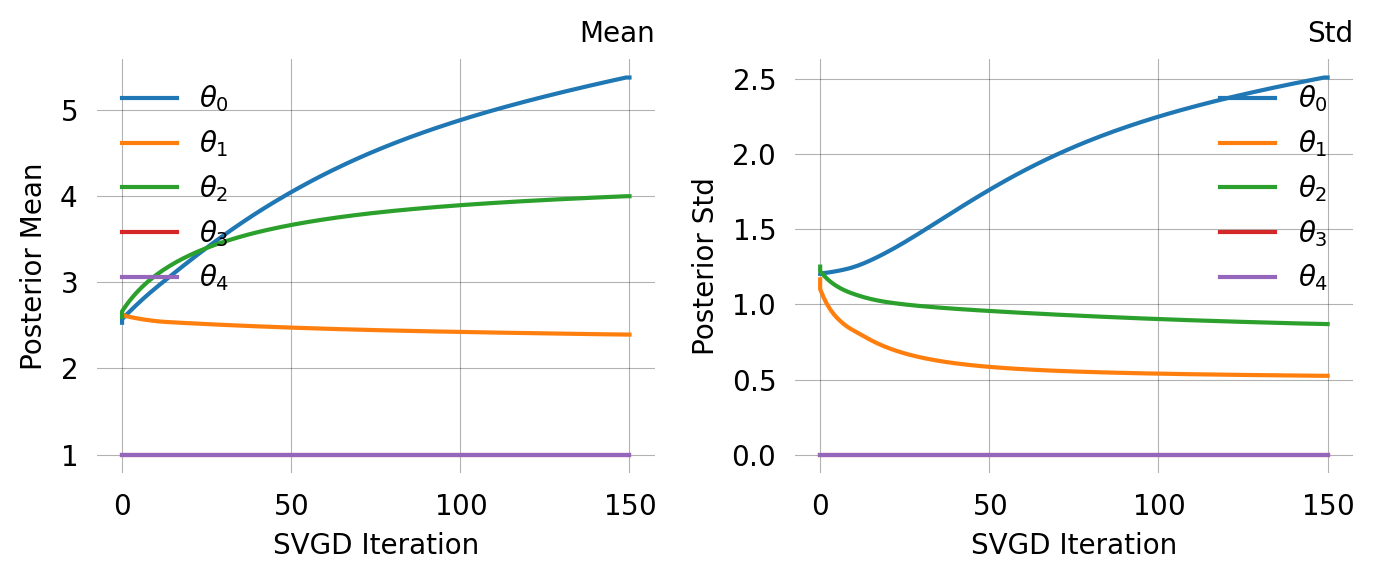

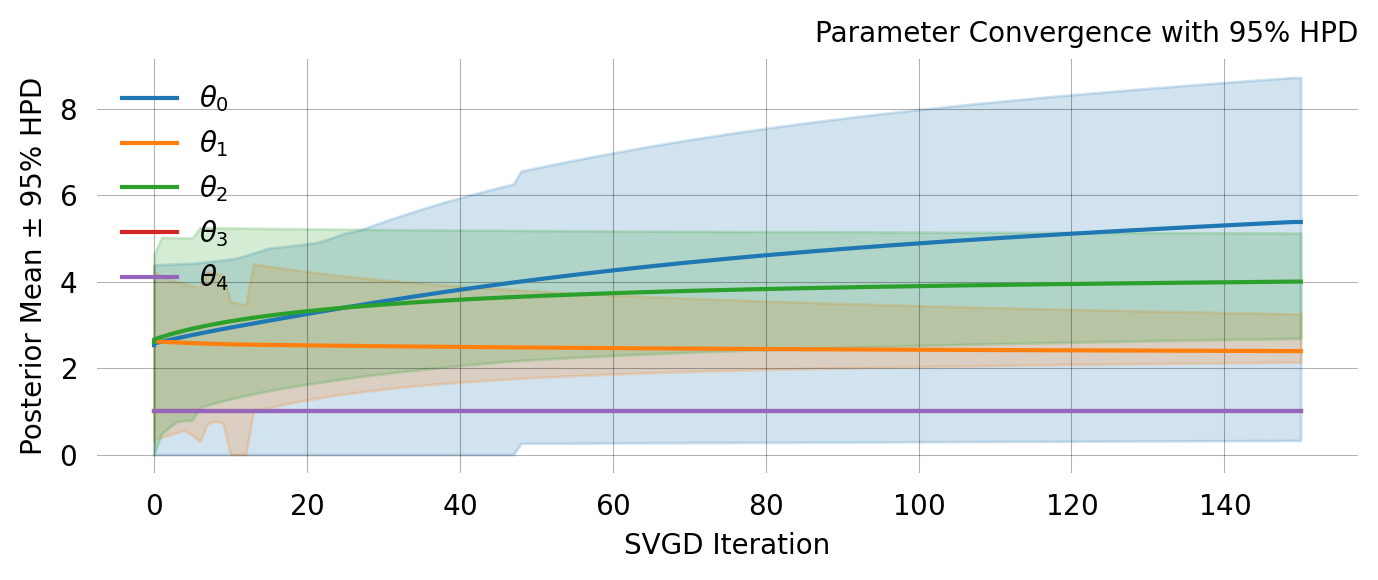

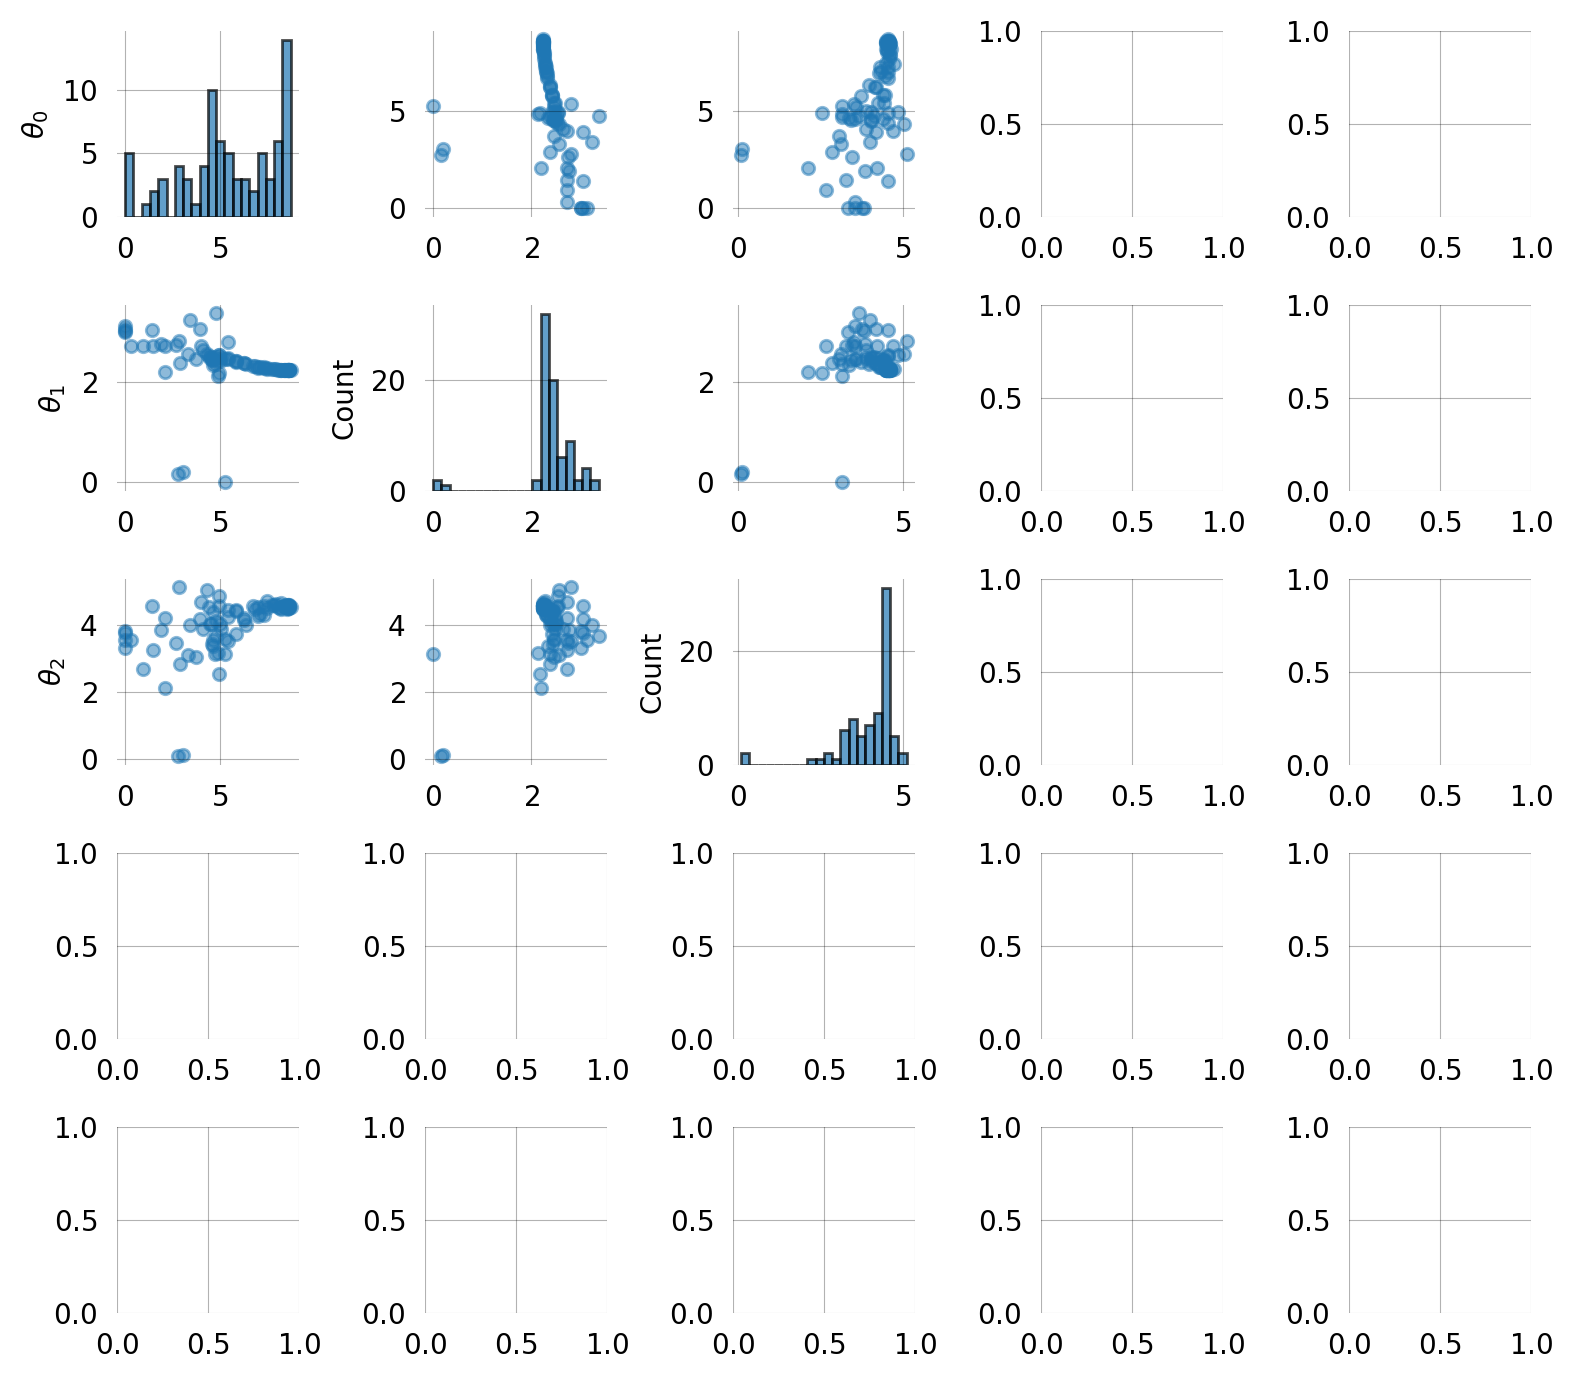

<Figure size 500x370 with 0 Axes>

In [30]:
# Konvergensplot og posterior CI for Yellow baboon
svgd_yellow.plot_convergence()

svgd_yellow.plot_ci(ci_method="hpd")

svgd_yellow.plot_pairwise()
plt.suptitle("Posterior pairwise — Yellow baboon\n(korrelation mellem Ne per epoke)")
plt.show()